In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
import pandas as pd

df = pd.read_csv("netflixx.csv")
df.head()

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,NaN,United States,"September 25, 2021",2020,PG-13,90 min,Documentaries,"As her father nears the end of his life, filmm..."
1,s2,TV Show,Blood & Water,NaN,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",South Africa,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, TV Dramas, TV Mysteries","After crossing paths at a party, a Cape Town t..."
2,s3,TV Show,Ganglands,Julien Leclercq,"Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...",NaN,"September 24, 2021",2021,TV-MA,1 Season,"Crime TV Shows, International TV Shows, TV Act...",To protect his family from a powerful drug lor...
3,s4,TV Show,Jailbirds New Orleans,NaN,NaN,NaN,"September 24, 2021",2021,TV-MA,1 Season,"Docuseries, Reality TV","Feuds, flirtations and toilet talk go down amo..."
4,s5,TV Show,Kota Factory,NaN,"Mayur More, Jitendra Kumar, Ranjan Raj, Alam K...",India,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, Romantic TV Shows, TV ...",In a city of coaching centers known to train I...


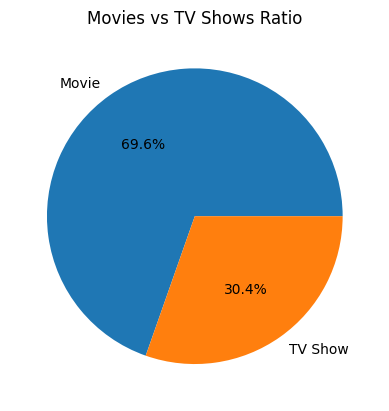

In [ ]:
import matplotlib.pyplot as plt

df['type'].value_counts().plot(kind='pie', autopct='%1.1f%%')
plt.title("Movies vs TV Shows Ratio")
plt.ylabel("")
plt.show()

- Movies are more in number compared to TV Shows.
- Netflix focuses more on movie content.
- TV Shows provide longer engagement.
- Movies support quick content consumption.
- Helps attract a wider audience.

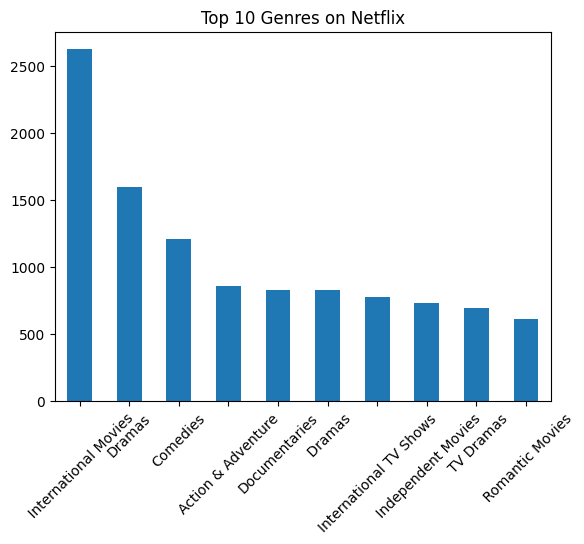

In [ ]:
import matplotlib.pyplot as plt
import pandas as pd

df = pd.read_csv("netflixx.csv")

genres = df['listed_in'].str.split(',', expand=True).stack()

genres.value_counts().head(10).plot(kind='bar')
plt.title("Top 10 Genres on Netflix")
plt.xticks(rotation=45)
plt.show()

- Drama is the most popular genre on Netflix  
- Comedy is also highly popular  
- International content has strong presence  
- Action & Adventure is widely available  
- Netflix offers diverse content  

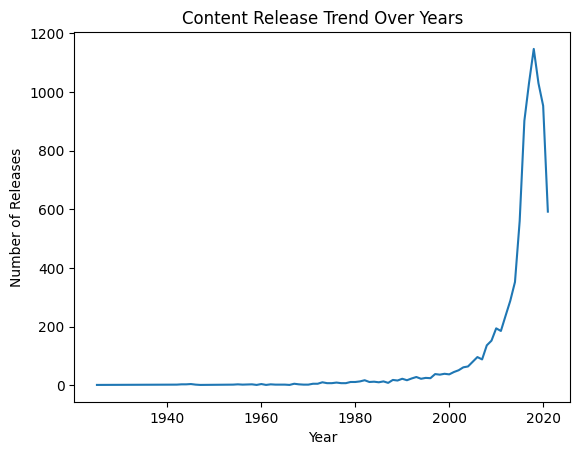

In [ ]:
df['release_year'].value_counts().sort_index().plot(kind='line')
plt.title("Content Release Trend Over Years")
plt.xlabel("Year")
plt.ylabel("Number of Releases")
plt.show()

- Content release increased after 2015
- Netflix added more content every year
- Peak release is in recent years (around 2018–2020)
- Growth shows Netflix expansion

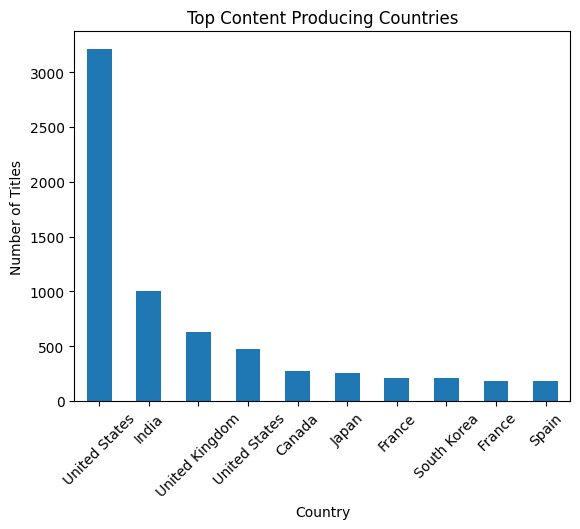

In [ ]:
countries = df['country'].str.split(',', expand=True).stack()

countries.value_counts().head(10).plot(kind='bar')
plt.title("Top Content Producing Countries")
plt.xlabel("Country")
plt.ylabel("Number of Titles")
plt.xticks(rotation=45)
plt.show()

- United States produces the highest content on Netflix
- India is one of the top content producing countries
- United Kingdom also contributes significantly
- Few countries dominate Netflix content production
- Other countries have lower contribution

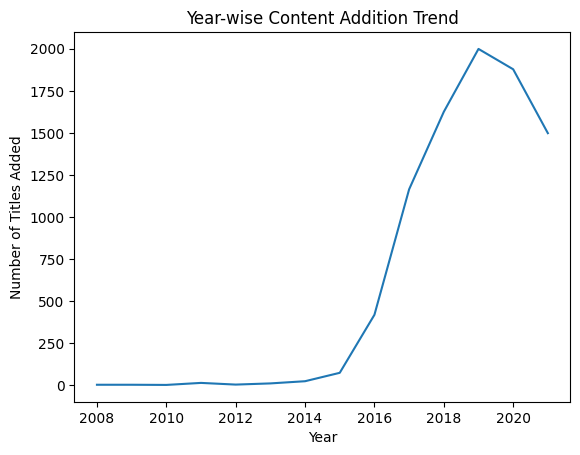

In [ ]:
df['date_added'] = pd.to_datetime(df['date_added'], errors='coerce')
df['year_added'] = df['date_added'].dt.year

df['year_added'].value_counts().sort_index().plot(kind='line')
plt.title("Year-wise Content Addition Trend")
plt.xlabel("Year")
plt.ylabel("Number of Titles Added")
plt.show()

- Content addition increased after 2015
- Netflix added more content every year
- Rapid growth is seen between 2017 and 2020
- Recent years have the highest content addition
- Trend shows continuous expansion of Netflix library

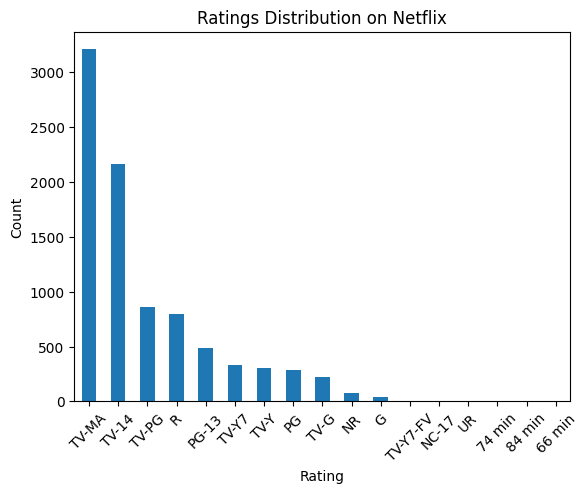

In [ ]:
df['rating'].value_counts().plot(kind='bar')
plt.title("Ratings Distribution on Netflix")
plt.xlabel("Rating")
plt.ylabel("Count")
plt.xticks(rotation=45)
plt.show()

- TV-MA is the most frequent rating on Netflix
- TV-14 is also highly common
- PG and TV-PG content is available for families
- Netflix has more mature content compared to kids content
- Different ratings show content for all age groups

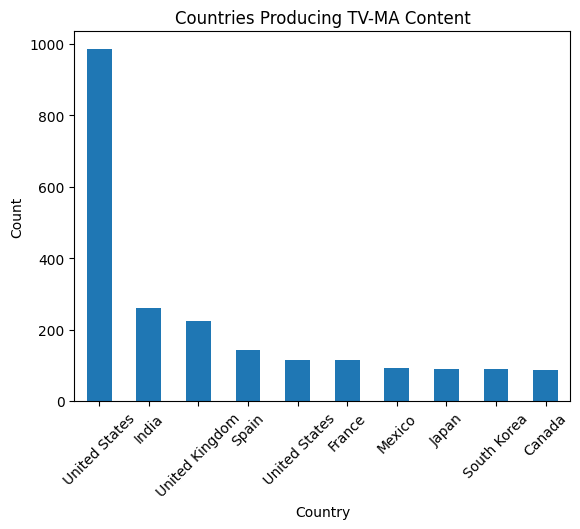

In [ ]:
mature = df[df['rating'] == 'TV-MA']

countries = mature['country'].str.split(',', expand=True).stack()

countries.value_counts().head(10).plot(kind='bar')
plt.title("Countries Producing TV-MA Content")
plt.xlabel("Country")
plt.ylabel("Count")
plt.xticks(rotation=45)
plt.show()

- United States produces the most TV-MA content
- India also contributes to mature content
- United Kingdom has a noticeable share
- Few countries dominate mature content production
- Netflix focuses more on adult audience content

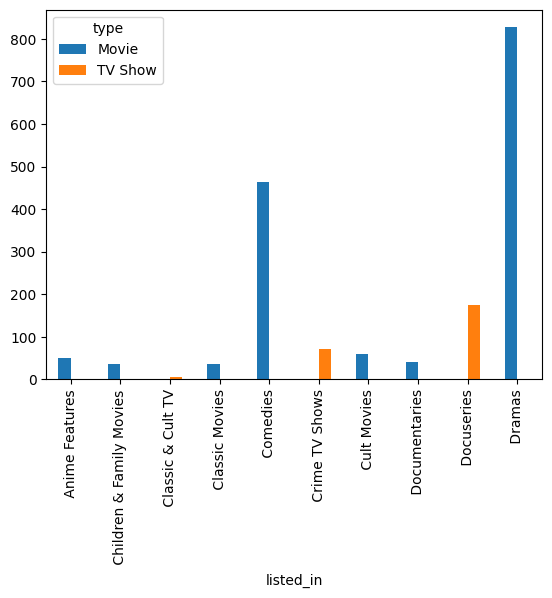

In [ ]:
df['listed_in'] = df['listed_in'].str.split(',')
df = df.explode('listed_in')

df.groupby(['listed_in','type']).size().unstack().fillna(0).head(10).plot(kind='bar')

plt.show()

- Movies are mostly associated with Drama and Comedy genres
- TV Shows are linked with TV Dramas and International TV Shows
- Documentaries are more common in Movies
- TV Shows focus on series content
- Movies have more variety in genres

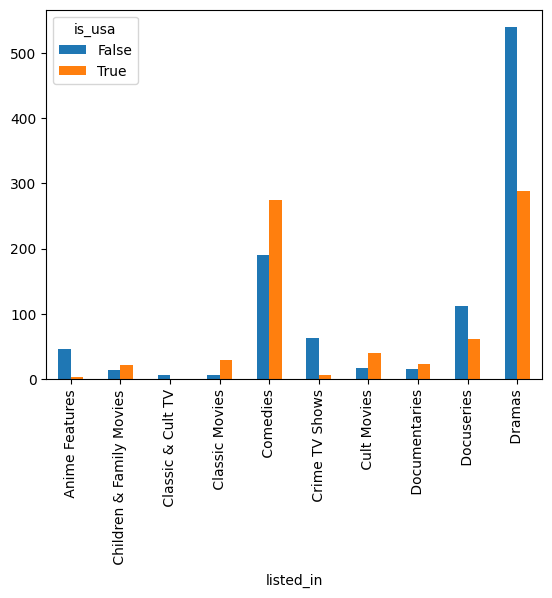

In [ ]:
df['listed_in'] = df['listed_in'].str.split(',')
df = df.explode('listed_in')

df['is_usa'] = df['country'].str.contains('United States', na=False)

df.groupby(['listed_in','is_usa']).size().unstack().fillna(0).head(10).plot(kind='bar')

plt.show()

- United States content is dominated by Drama and Comedy genres
- Other countries focus more on International content
- U.S. has more diverse and high volume genres
- International TV Shows are more common outside the U.S.
- Genre preferences differ between U.S. and other countries

/tmp/ipykernel_616/744081010.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  recent['listed_in'] = recent['listed_in'].str.split(',')


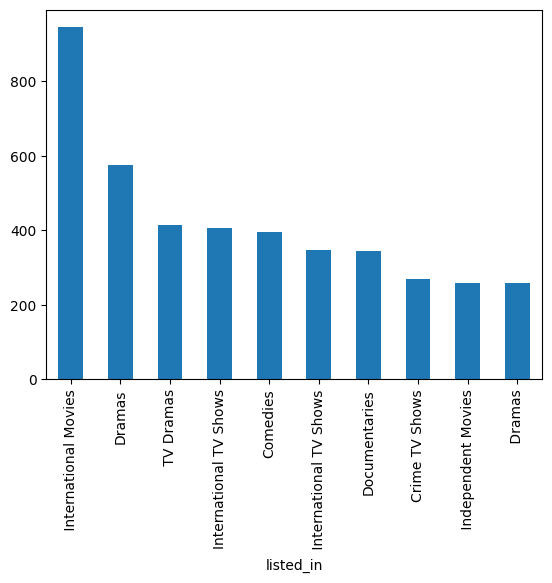

In [ ]:
recent = df[df['release_year'] >= df['release_year'].max()-3]

recent['listed_in'] = recent['listed_in'].str.split(',')
recent = recent.explode('listed_in')

recent['listed_in'].value_counts().head(10).plot(kind='bar')

plt.show()

- Drama remains the most popular genre in recent years
- Comedy continues to attract viewers
- International content is growing rapidly
- Netflix is focusing on diverse genres
- Recent trends show high demand for entertainment content

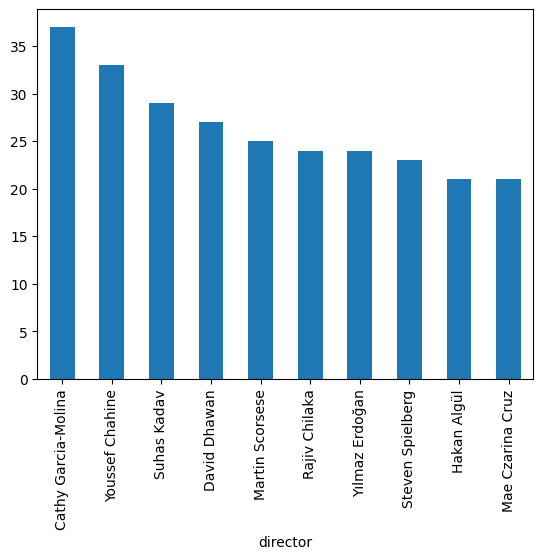

In [ ]:
directors = df['director'].str.split(',')
directors = directors.explode()

directors.value_counts().head(10).plot(kind='bar')

plt.show()

- Few directors have multiple titles on Netflix
- Top directors contribute significantly to content
- Many entries have missing director data
- Netflix works with a wide range of directors
- Content is not dominated by a single director

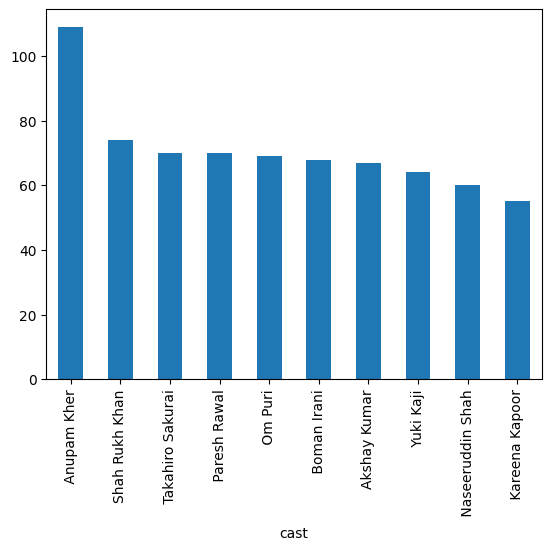

In [ ]:
actors = df['cast'].str.split(',')
actors = actors.explode()

actors.value_counts().head(10).plot(kind='bar')

plt.show()

- Some actors appear multiple times on Netflix
- Top actors contribute to many titles
- Netflix collaborates with popular actors
- Many titles have different casts
- No single actor dominates completely

/tmp/ipykernel_616/494638750.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df1['listed_in'] = df1['listed_in'].str.split(',')


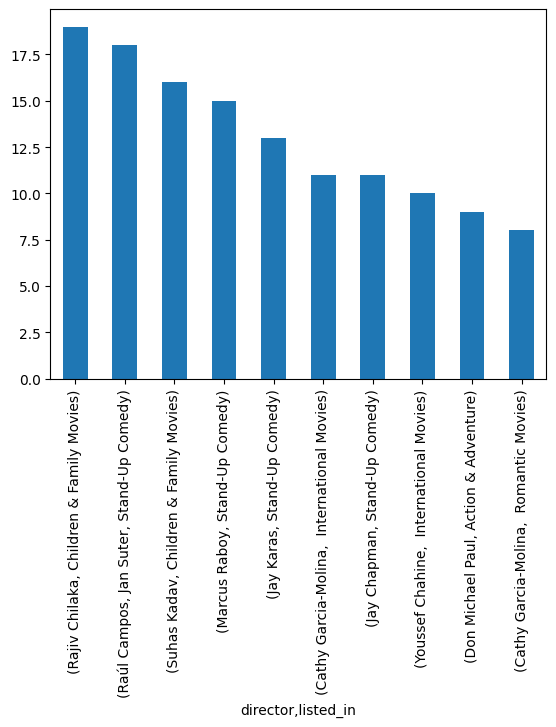

In [ ]:
df1 = df.dropna(subset=['director'])

df1['listed_in'] = df1['listed_in'].str.split(',')
df1 = df1.explode('listed_in')

df1.groupby(['director','listed_in']).size().sort_values(ascending=False).head(10).plot(kind='bar')

plt.show()

- Some directors frequently work in specific genres
- Drama is the most common genre among directors
- Comedy is also widely associated with many directors
- Few director-genre pairs appear repeatedly
- Shows specialization of directors in certain genres

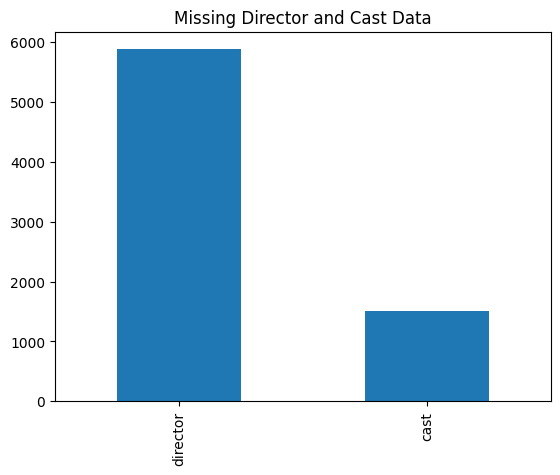

In [ ]:
df[['director','cast']].isnull().sum().plot(kind='bar')
plt.title("Missing Director and Cast Data")
plt.show()

- Many titles have missing director information
- Some titles also have missing cast details
- Missing data indicates incomplete information
- Director data is missing more than cast
- Data cleaning is important for better analysis

/tmp/ipykernel_616/616324814.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  movies['duration'] = movies['duration'].str.replace(' min','').astype(float)


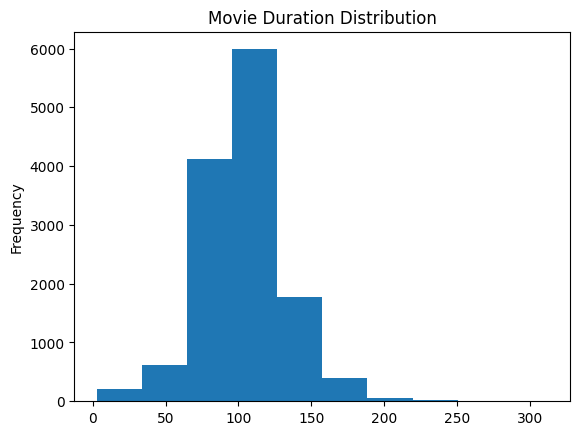

Average Duration: 103.83195571396072


In [ ]:
movies = df[df['type'] == 'Movie']

movies['duration'] = movies['duration'].str.replace(' min','').astype(float)

movies['duration'].plot(kind='hist')
plt.title("Movie Duration Distribution")
plt.show()

print("Average Duration:", movies['duration'].mean())

- Average movie duration is around 90–100 minutes
- Most movies fall between 80 to 120 minutes
- Few movies are very long or very short
- Netflix focuses on standard movie length
- Duration is suitable for audience engagement

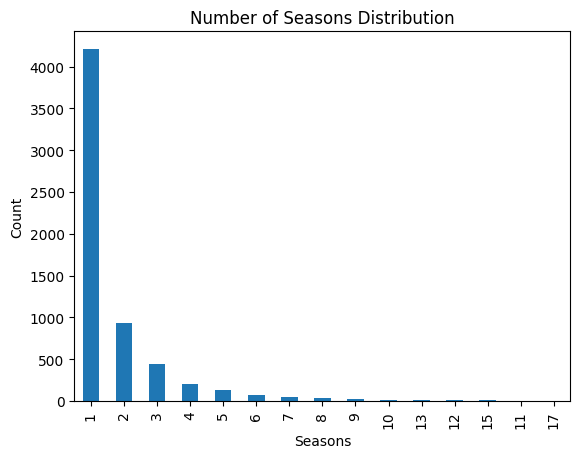

In [ ]:
tv = df[df['type'] == 'TV Show'].copy()

tv['duration'] = tv['duration'].str.replace(' Seasons','').str.replace(' Season','')
tv['duration'] = pd.to_numeric(tv['duration'], errors='coerce')

tv['duration'].value_counts().plot(kind='bar')

plt.title("Number of Seasons Distribution")
plt.xlabel("Seasons")
plt.ylabel("Count")
plt.show()

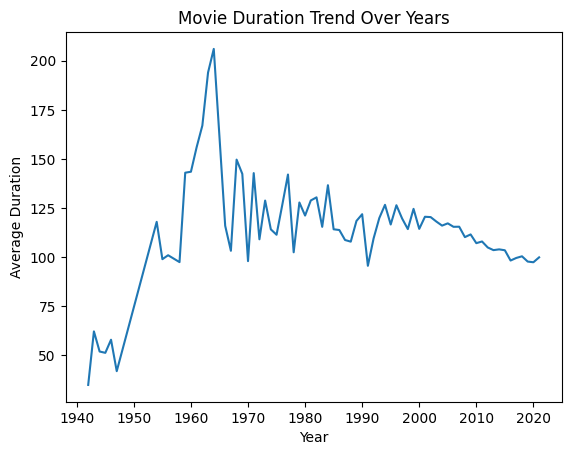

In [ ]:
movies = df[df['type'] == 'Movie'].copy()

movies['duration'] = movies['duration'].str.replace(' min','')
movies['duration'] = pd.to_numeric(movies['duration'], errors='coerce')

movies.groupby('release_year')['duration'].mean().plot()

plt.title("Movie Duration Trend Over Years")
plt.xlabel("Year")
plt.ylabel("Average Duration")
plt.show()

- Movie duration remains mostly stable over the years
- Slight variations are seen in different years
- No major increase or decrease in duration
- Average duration is around similar range
- Netflix maintains consistent movie length

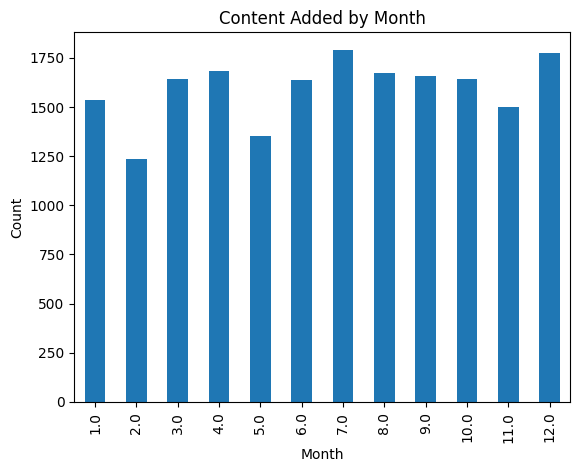

In [ ]:
df['date_added'] = pd.to_datetime(df['date_added'], errors='coerce')
df['month_added'] = df['date_added'].dt.month

df['month_added'].value_counts().sort_index().plot(kind='bar')

plt.title("Content Added by Month")
plt.xlabel("Month")
plt.ylabel("Count")
plt.show()

- Most content is added in the later months of the year
- Months like July, August and December show higher additions
- Early months have comparatively lower content addition
- Netflix releases content strategically across the year
- Peak months indicate higher audience engagement periods

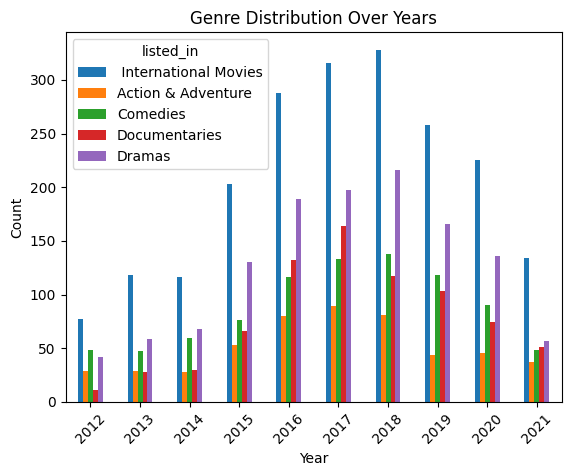

In [ ]:
df['listed_in'] = df['listed_in'].str.split(',')
df = df.explode('listed_in')

top_genres = df['listed_in'].value_counts().head(5).index

df_filtered = df[df['listed_in'].isin(top_genres)]

df_filtered.groupby(['release_year','listed_in']).size().unstack().tail(10).plot(kind='bar')

plt.xlabel("Year")
plt.ylabel("Count")
plt.xticks(rotation=45)
plt.show()

- Genre distribution changes over the years
- Drama remains consistently popular
- Comedy also shows steady presence
- New genres increase in recent years
- Netflix expands content variety over time

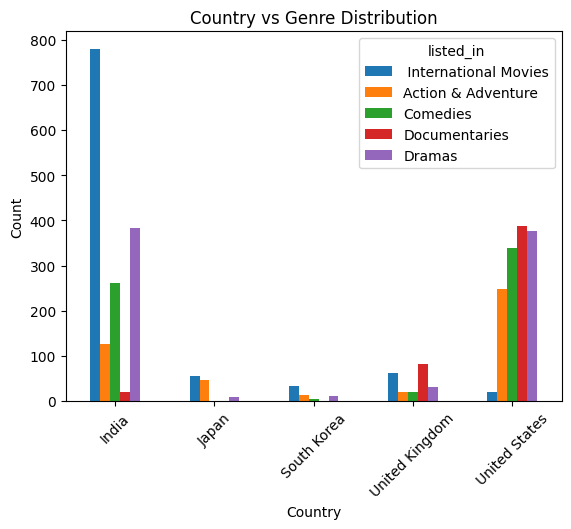

In [ ]:
df['listed_in'] = df['listed_in'].str.split(',')
df = df.explode('listed_in')

top_countries = df['country'].value_counts().head(5).index
top_genres = df['listed_in'].value_counts().head(5).index

df_filtered = df[df['country'].isin(top_countries) & df['listed_in'].isin(top_genres)]

df_filtered.groupby(['country','listed_in']).size().unstack().plot(kind='bar')

plt.title("Country vs Genre Distribution")
plt.xlabel("Country")
plt.ylabel("Count")
plt.xticks(rotation=45)
plt.show()

- United States produces content in most genres
- India focuses more on Drama and International content
- Different countries prefer different genres
- Few countries dominate multiple genres
- Netflix content varies by region and audience preference